In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/iris/Iris.csv')  # adjust path if needed
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [4]:
grouped_stats = df.groupby('Species').agg(['mean', 'median', 'min', 'max', 'std'])
grouped_stats

Id                            SepalLengthCm              \
                  mean median  min  max       std          mean median  min   
Species                                                                       
Iris-setosa       25.5   25.5    1   50  14.57738         5.006    5.0  4.3   
Iris-versicolor   75.5   75.5   51  100  14.57738         5.936    5.9  4.9   
Iris-virginica   125.5  125.5  101  150  14.57738         6.588    6.5  4.9   

                                ... PetalLengthCm                             \
                 max       std  ...          mean median  min  max       std   
Species                         ...                                            
Iris-setosa      5.8  0.352490  ...         1.464   1.50  1.0  1.9  0.173511   
Iris-versicolor  7.0  0.516171  ...         4.260   4.35  3.0  5.1  0.469911   
Iris-virginica   7.9  0.635880  ...         5.552   5.55  4.5  6.9  0.551895   

                PetalWidthCm                             
                        mean median  min  max       std  
Species                                                  
Iris-setosa            0.244    0.2  0.1  0.6  0.107210  
Iris-versicolor        1.326    1.3  1.0  1.8  0.197753  
Iris-virginica         2.026    2.0  1.4  2.5  0.274650  

[3 rows x 25 columns]

In [5]:
grouped_list = df.groupby('Species')['PetalLengthCm'].apply(list)
grouped_list

Species
Iris-setosa        [1.4, 1.4, 1.3, 1.5, 1.4, 1.7, 1.4, 1.5, 1.4, ...
Iris-versicolor    [4.7, 4.5, 4.9, 4.0, 4.6, 4.5, 4.7, 3.3, 4.6, ...
Iris-virginica     [6.0, 5.1, 5.9, 5.6, 5.8, 6.6, 4.5, 6.3, 5.8, ...
Name: PetalLengthCm, dtype: object

In [6]:
species_list = df['Species'].unique()

for sp in species_list:
    print("\nStatistics for:", sp)
    
    subset = df[df['Species'] == sp]
    
    # Select only numeric columns (VERY IMPORTANT)
    subset_numeric = subset.select_dtypes(include=[np.number])
    
    print("\nMean:\n", subset_numeric.mean())
    print("\nStandard Deviation:\n", subset_numeric.std())
    print("\nPercentiles:\n", subset_numeric.quantile([0.25, 0.5, 0.75]))


Statistics for: Iris-setosa

Mean:
 Id               25.500
SepalLengthCm     5.006
SepalWidthCm      3.418
PetalLengthCm     1.464
PetalWidthCm      0.244
dtype: float64

Standard Deviation:
 Id               14.577380
SepalLengthCm     0.352490
SepalWidthCm      0.381024
PetalLengthCm     0.173511
PetalWidthCm      0.107210
dtype: float64

Percentiles:
          Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0.25  13.25            4.8         3.125          1.400           0.2
0.50  25.50            5.0         3.400          1.500           0.2
0.75  37.75            5.2         3.675          1.575           0.3

Statistics for: Iris-versicolor

Mean:
 Id               75.500
SepalLengthCm     5.936
SepalWidthCm      2.770
PetalLengthCm     4.260
PetalWidthCm      1.326
dtype: float64

Standard Deviation:
 Id               14.577380
SepalLengthCm     0.516171
SepalWidthCm      0.313798
PetalLengthCm     0.469911
PetalWidthCm      0.197753
dtype: float64

Percentiles:

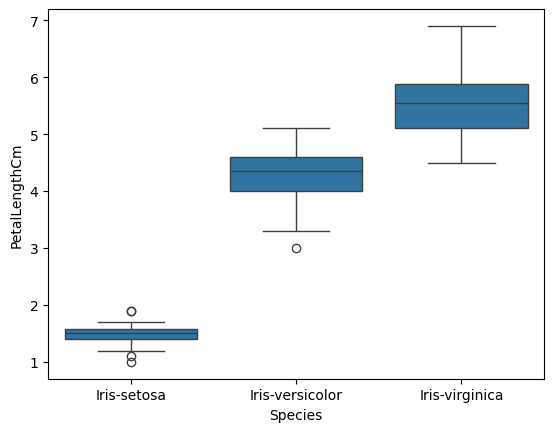

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Species', y='PetalLengthCm', data=df)
plt.show()